# AirBnB
https://insideairbnb.com/get-the-data/

https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2025-12-28/data/listings.csv.gz

In [1]:
import pandas as pd

In [2]:
# df = pd.read_csv('../listings.csv')
df = pd.read_csv('https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-03-30/data/listings.csv.gz')

In [3]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,17878,https://www.airbnb.com/rooms/17878,20260330062336,2026-04-02,city scrape,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",Please note that elevated rates apply for New ...,NaN,https://a0.muscache.com/pictures/65320518/3069...,68997,...,4.91,4.78,4.68,NaN,NaN,1,1,0,0,1.83
1,25026,https://www.airbnb.com/rooms/25026,20260330062336,2026-04-02,city scrape,Beautiful Modern Decorated Studio in Copacabana,"**Fully renovated in Dec 2022, new kitchen, n...",NaN,https://a0.muscache.com/pictures/7c08fa4f-1d7b...,102840,...,4.93,4.86,4.65,NaN,NaN,1,1,0,0,1.69
2,35764,https://www.airbnb.com/rooms/35764,20260330062336,2026-04-02,city scrape,COPACABANA SEA BREEZE - RIO - 25 X Superhost,Our newly renovated studio is located in the b...,NaN,https://a0.muscache.com/pictures/23782972/1d3e...,153691,...,4.95,4.95,4.89,NaN,NaN,1,1,0,0,2.90


In [4]:
df.room_type

0        Entire home/apt
1        Entire home/apt
2        Entire home/apt
3        Entire home/apt
4        Entire home/apt
              ...       
40764       Private room
40765    Entire home/apt
40766    Entire home/apt
40767    Entire home/apt
40768    Entire home/apt
Name: room_type, Length: 40769, dtype: str

In [5]:
df.name.info()

<class 'pandas.Series'>
RangeIndex: 40769 entries, 0 to 40768
Series name: name
Non-Null Count  Dtype
--------------  -----
40769 non-null  str  
dtypes: str(1)
memory usage: 1.8 MB


In [6]:
df['len_name'] = df['name'].str.len().fillna(0).astype(int)
df['len_description'] = df['description'].str.len().fillna(0).astype(int)

In [7]:
col_interes = ['id', 'name', 'len_description', 'len_name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [8]:
df_treatment = df[col_interes].copy()

In [9]:
df_treatment.head(3)

,id,name,len_description,len_name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",533,49,Matthias,"Rio de Janeiro, Brazil",NaN,t,NaN,Copacabana,...,5,1.0,2.0,2.0,$565.00,5.0,350,1,4.72,NaN
1,25026,Beautiful Modern Decorated Studio in Copacabana,524,47,Viviane,"Rio de Janeiro, Brazil",NaN,t,NaN,Copacabana,...,3,1.0,1.0,2.0,$542.50,2.0,325,2,4.76,NaN
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,314,47,Patricia&Paulo,"Rio de Janeiro, Brazil",NaN,t,NaN,Copacabana,...,2,1.5,1.0,1.0,$369.00,3.0,548,5,4.90,NaN


In [10]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [11]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 40769 entries, 0 to 40768
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      40769 non-null  int64  
 1   name                    40769 non-null  str    
 2   len_description         40769 non-null  int64  
 3   len_name                40769 non-null  int64  
 4   host_name               40718 non-null  str    
 5   host_location           31586 non-null  str    
 6   host_response_time      0 non-null      float64
 7   host_is_superhost       40718 non-null  str    
 8   neighbourhood           0 non-null      float64
 9   neighbourhood_cleansed  40769 non-null  str    
 10  latitude                40769 non-null  float64
 11  longitude               40769 non-null  float64
 12  property_type           40769 non-null  str    
 13  room_type               40756 non-null  str    
 14  accommodates            40769 non-null  int64  
 

In [12]:
df.host_response_time.value_counts()

Series([], Name: count, dtype: int64)

In [13]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [14]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [15]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [16]:
pd.set_option('display.max_rows', 10)

In [17]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [18]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

# 3. Verifique o resultado
print(df_treatment[['neighbourhood_cleansed', 'bairro_perigoso']].head(100))

      neighbourhood_cleansed  bairro_perigoso
0                 Copacabana                0
1                 Copacabana                0
2                 Copacabana                0
3                    Ipanema                0
4                 Copacabana                0
..                       ...              ...
95  Recreio dos Bandeirantes                0
96              Santa Teresa                0
97                    Leblon                0
98           Barra da Tijuca                0
99                   Ipanema                0

[100 rows x 2 columns]


In [19]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns 

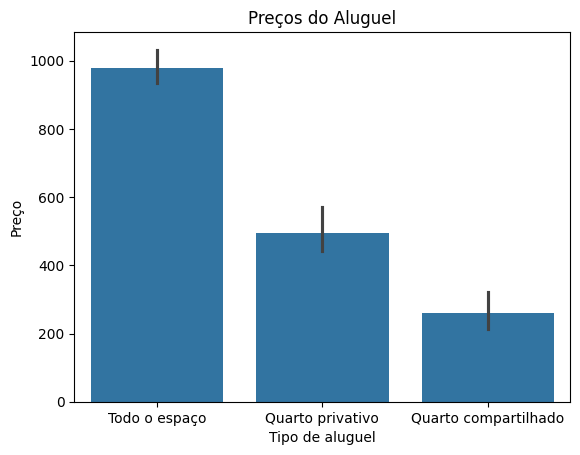

In [21]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

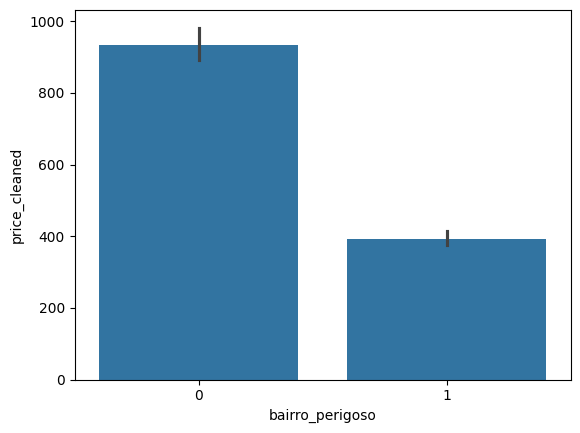

In [22]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [23]:
df_treatment.minimum_nights.describe()

count    40737.000000
mean         2.045978
std          1.214792
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         30.000000
Name: minimum_nights, dtype: float64

In [24]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [25]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 40769 entries, 0 to 40768
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      40769 non-null  int64  
 1   name                    40769 non-null  str    
 2   len_description         40769 non-null  int64  
 3   len_name                40769 non-null  int64  
 4   host_name               40718 non-null  str    
 5   host_location           31586 non-null  str    
 6   host_response_time      40769 non-null  object 
 7   host_is_superhost       40769 non-null  bool   
 8   neighbourhood           0 non-null      float64
 9   neighbourhood_cleansed  40769 non-null  str    
 10  latitude                40769 non-null  float64
 11  longitude               40769 non-null  float64
 12  property_type           40769 non-null  str    
 13  room_type               40756 non-null  str    
 14  accommodates            40769 non-null  int64  
 

In [26]:
df_treatment.price_cleaned.describe()

count     39816.000000
mean        889.774473
std        4207.023574
min          42.400000
25%         330.000000
50%         500.285000
75%         827.500000
max      570726.000000
Name: price_cleaned, dtype: float64

**💡 Evidência de Outliers nos Preços**

A distribuição dos preços apresenta fortes indícios de valores discrepantes (outliers):

- Média inflacionada: A média está em 4.388, enquanto o terceiro quartil (75%) é de apenas 565 (ou seja, 75% dos anúncios custam até 565).
- Alta dispersão: O desvio padrão supera o valor do próprio percentil de 75%, mostrando uma variação extrema.
- Máximo discrepante: O valor máximo está excessivamente alto em comparação com o restante dos dados.

Ação: Vamos realizar o corte (trimming) desses outliers acima de 1000 para normalizar a análise.

In [27]:
df_treatment = df_treatment[df_treatment["price_cleaned"] <=2000] 
df_treatment.price_cleaned.describe()

count    37468.000000
mean       582.948186
std        374.399478
min         42.400000
25%        320.000000
50%        474.000000
75%        742.000000
max       2000.000000
Name: price_cleaned, dtype: float64

In [28]:
37468/39816

0.9410287321679727

Perdemos somentos 7400 dados de 39800 dados, então não perderemos tantos dados que afete a nossa análise

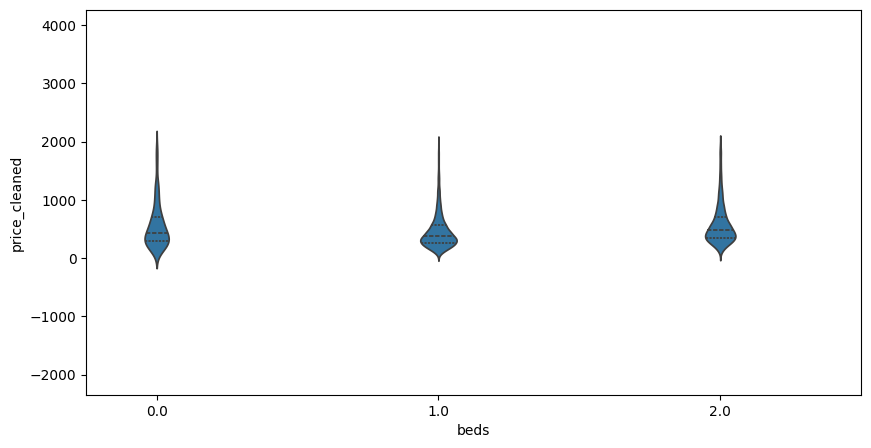

In [29]:
import seaborn as sns

plt.figure(figsize=[10,5])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()


0 camas nos anuncios? Provavelmente algum erro dos anuncios, portanto vamos verificar a quantidade que isso ocorre, se o melhor a se fazer é limpar, ou arrumar automaticamente

In [30]:
print("A quantidade de quartos com 0 camas é:", len(df_treatment[df_treatment["beds"] == 0]))

print("A quantidade total de anuncios é:", len(df_treatment))

A quantidade de quartos com 0 camas é: 317
A quantidade total de anuncios é: 37468


Pode ser limpo esses dados sem problemas na análise

In [31]:
df_treatment = df_treatment[df_treatment["beds"]>0]

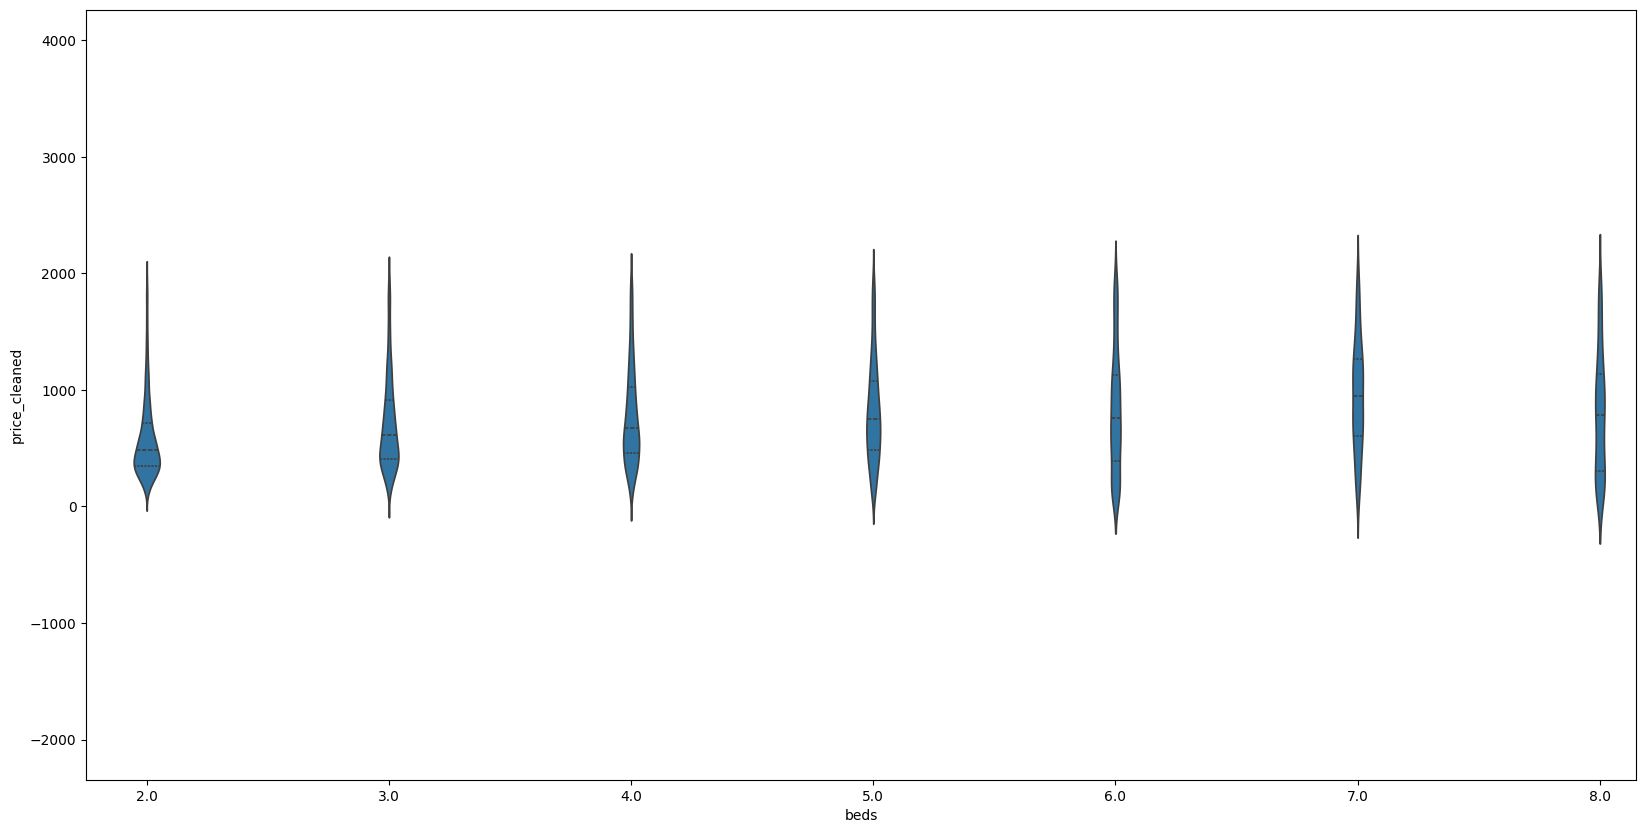

In [32]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(.75,7.15)

plt.show()


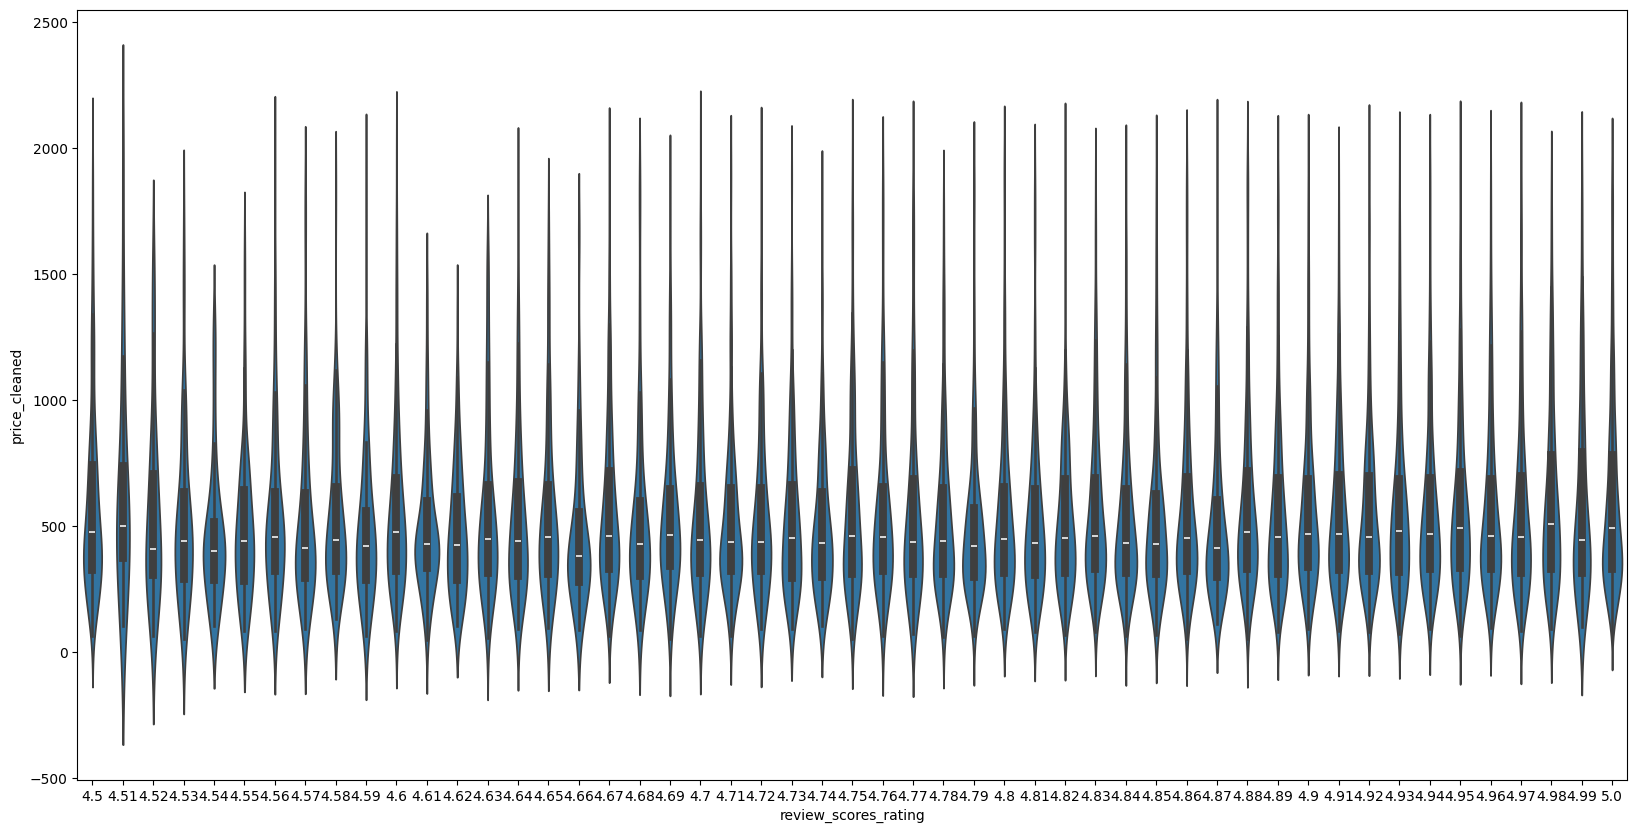

In [33]:
import seaborn as sns

plt.figure(figsize=[20,10])

df_plot_filtrado = df_treatment[
    df_treatment["review_scores_rating"].between(4.5, 5)
]

ax = sns.violinplot(x="review_scores_rating", y="price_cleaned", data=df_plot_filtrado)

# plt.xlim(4,5.1)

plt.show()


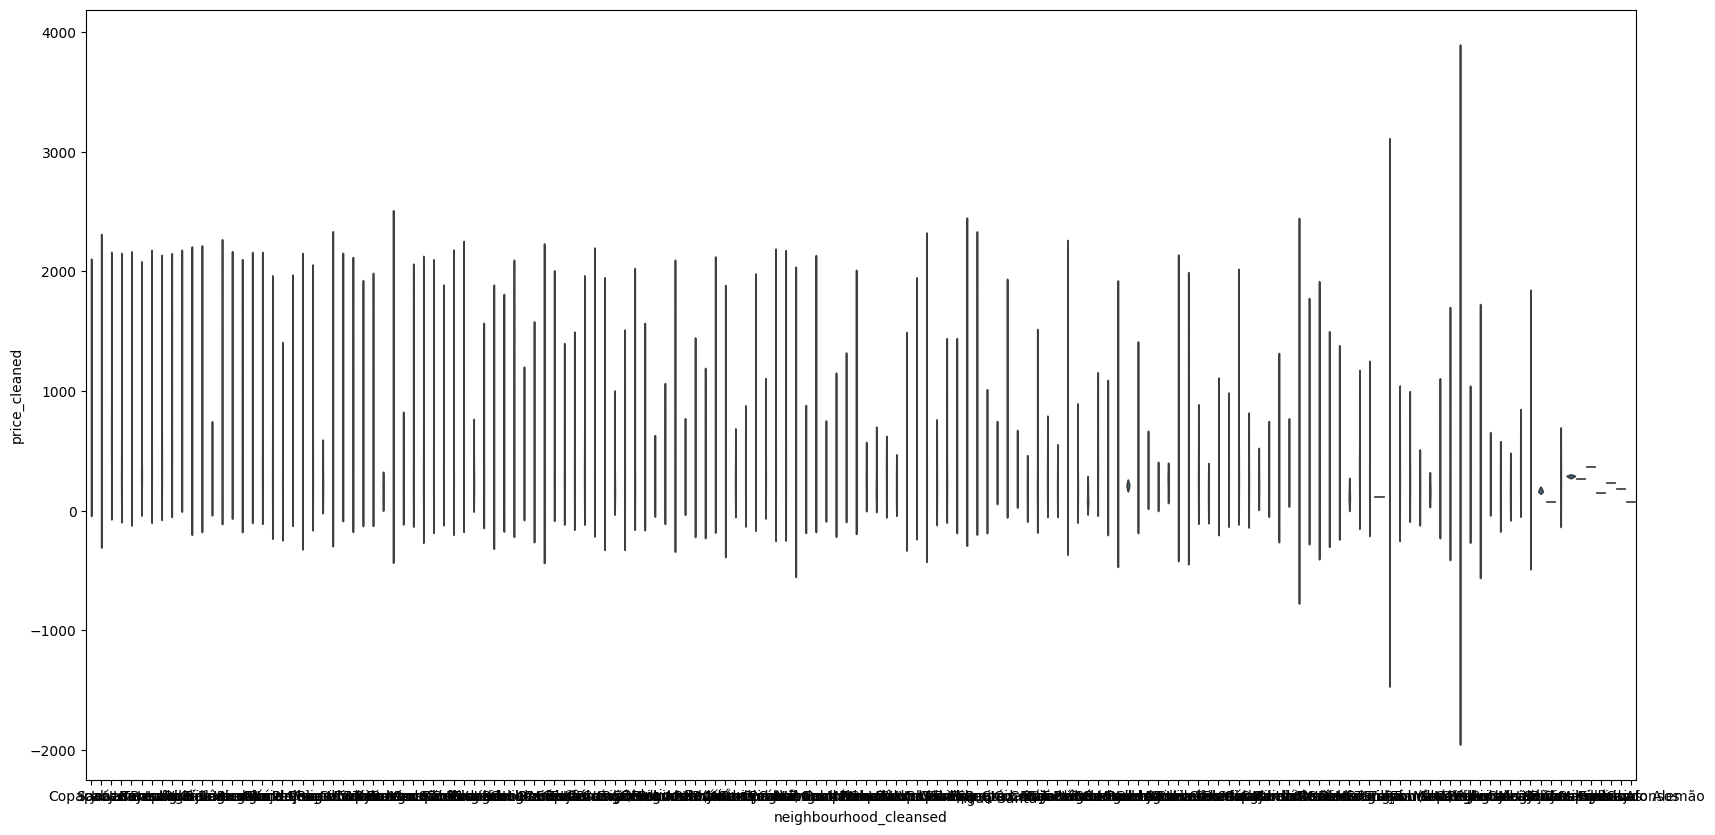

In [34]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="neighbourhood_cleansed", y="price_cleaned", data=df_treatment, inner=None)

# ax.set_yscale("log")

plt.show()


In [35]:
df_treatment['bairro_perigoso'].value_counts()

bairro_perigoso
0    34049
1     3090
Name: count, dtype: int64

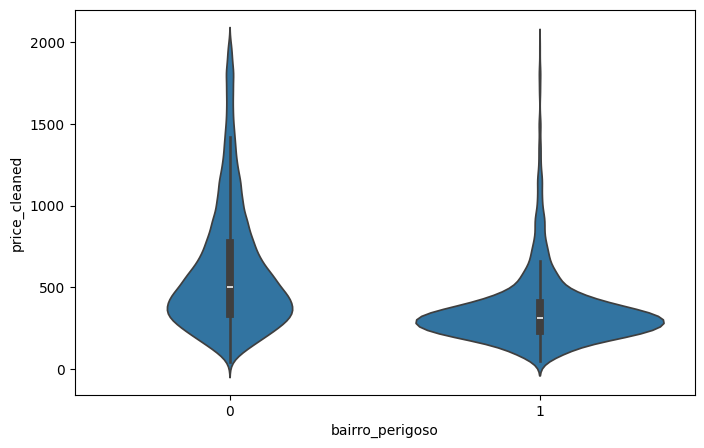

In [36]:
import seaborn as sns

plt.figure(figsize=[8,5])

ax = sns.violinplot(x="bairro_perigoso", y="price_cleaned", data=df_treatment)

# plt.xlim(4,5.1)

plt.show()


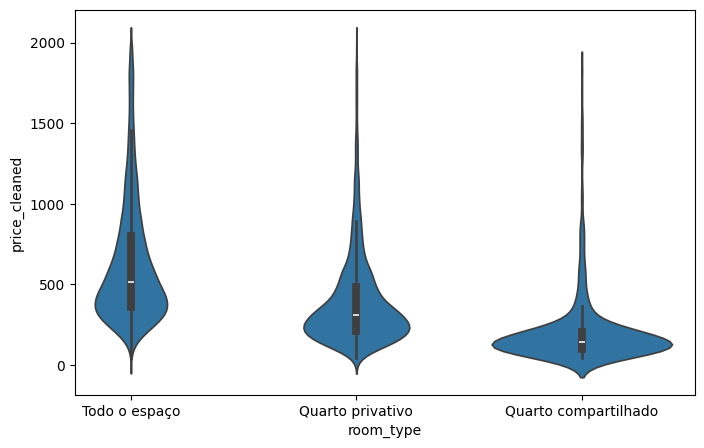

In [37]:
plt.figure(figsize=[8,5])

ax = sns.violinplot(df_treatment, x='room_type', y='price_cleaned')

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()

# Previsão de Preços

## Regressão sem Cuidado de Bairros ou Tipo de Quartos


### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'bairro_perigoso', 
    'room_type', 'review_scores_rating','len_description', 'len_name'
    ]].copy()

df_arvore_regressora.dropna(inplace=True)

Primeiro vamos tratar separando os room types

In [39]:
df_arvore_regressora.room_type.value_counts()

room_type
Todo o espaço           26129
Quarto privativo         4775
Quarto compartilhado      333
Name: count, dtype: int64

In [40]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

Text(0.5, 1.0, 'Correlation Heatmap')

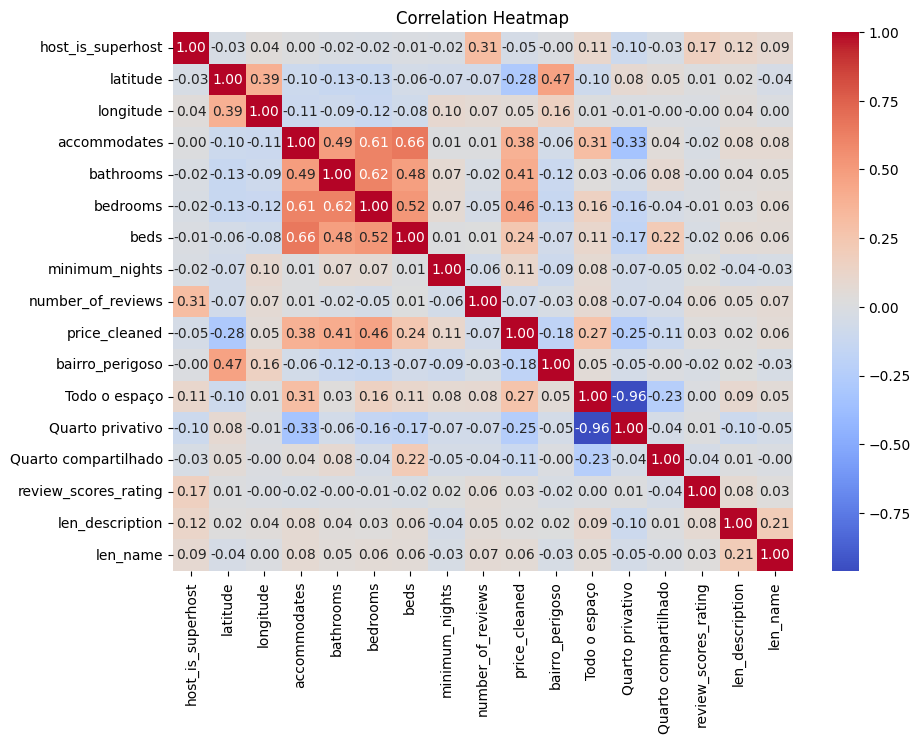

In [41]:
corr = df_arvore_regressora[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado', 'review_scores_rating', 'len_description', 'len_name'
]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [42]:
cat_cols = ['host_is_superhost', 'bairro_perigoso','Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

In [43]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [44]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=6, 
    min_samples_leaf=100,
    random_state=RANDOM_SEED
    )

In [45]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [46]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [47]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [48]:
y_pred_arvore = pipeline_arvore.predict(X_test)

In [49]:
print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.35236900162075724
Root mean squared error: 288.2599199921486


In [ ]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"RMSE do Dummy (Média): {root_mean_squared_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -1.5217388316779434e-05
RMSE do Dummy (Média): 358.20


Ou seja, nosso modelo está realmente tendo algum efeito quando comparado com a média, está performando melhor que sem um modelo

In [51]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_arvore      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro (%)'] = ((df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'])*100


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro (%)'] >=10].head())

             id_imovel  preço_real  preço_previsto   erro (%)
0  1037636533585056819       295.0      499.362049  69.275271
1   574839401335466159       349.0      473.789406  35.756277
2  1536431282011651972       277.2      388.451742  40.134106
5  1273016171526870692       455.0      620.508364  36.375465
7             40943750       993.0      388.921516  60.833684


### Regressão linear

Acredito que a arvore de decisão vai lidar melhor com esse tipo de dados, mas vamos testar com regressões lineares e robust scaler

In [52]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'room_type', 'review_scores_rating', 'len_description', 'len_name'
    ]].copy()

df_lasso.dropna(inplace=True)

In [53]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_lasso[['room_type']])
one_hot = enc.transform(df_lasso[['room_type']]).toarray()
df_lasso[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [54]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

In [55]:
X = df_lasso.drop(columns=['price_cleaned'])
y = df_lasso['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [56]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

In [57]:
print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

R² Score: 0.3177336388913389
Root mean squared error: 295.8676126449863


In [58]:
df_lasso = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_lasso      # A nota que a árvore calculou
})
df_lasso.reset_index(drop=True, inplace=True)
df_lasso['erro'] = (df_lasso['preço_real'] - df_lasso['preço_previsto']).abs() / df_lasso['preço_real'] 


fig = px.line(df_lasso, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_lasso[df_lasso['erro'] >=0.1].head())

             id_imovel  preço_real  preço_previsto      erro
0  1037636533585056819       295.0      552.728644  0.873656
1   574839401335466159       349.0      608.612292  0.743875
2  1536431282011651972       277.2      245.625465  0.113905
4  1328054328936074636      1085.0      929.237059  0.143560
5  1273016171526870692       455.0      532.782949  0.170952


## Regressão com Cuidado de Bairros ou Tipos de Quartos

### Bairros

In [59]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'len_description', 'len_name']


dfs_por_bairro = {
    nome_grupo: dados[colunas_desejadas].dropna()
    for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')
}

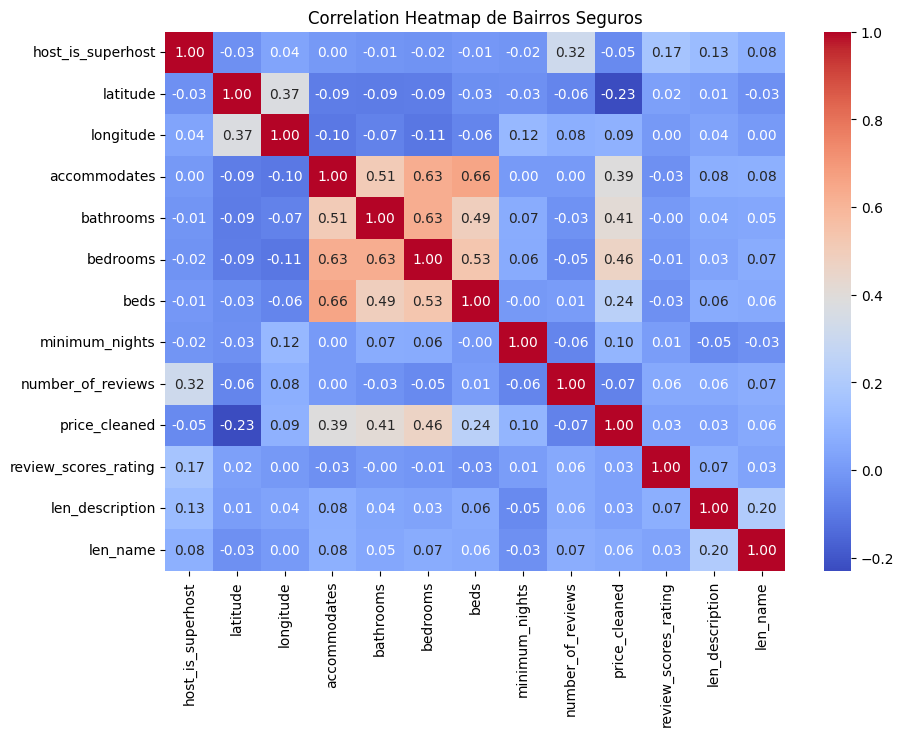

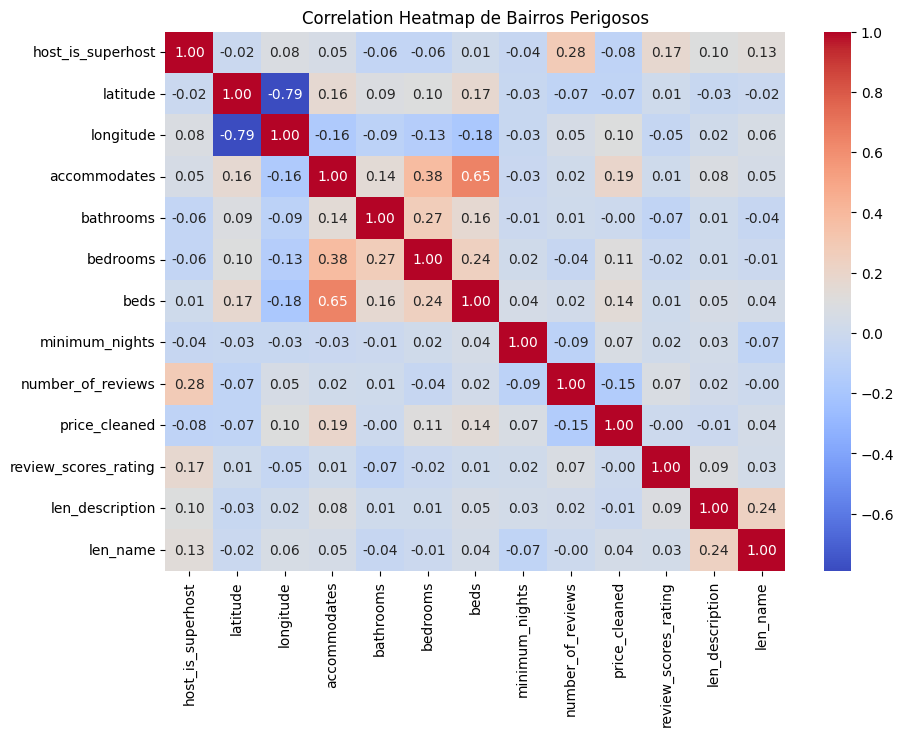

In [60]:
import seaborn as sns
plt.figure(figsize=(10, 7))
corr = dfs_por_bairro[0][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Seguros')
plt.show()

corr = dfs_por_bairro[1][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Perigosos')
plt.show()

In [61]:
cat_cols = ['host_is_superhost']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

In [62]:
for bairro, dfs_escolhido in dfs_por_bairro.items():
    print("Seguro" if bairro == 0 else "Perigoso")

Seguro
Perigoso


#### Arvore

In [63]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [64]:
modelos_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [ ]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_por_bairro[MODELO_ATUAL][status_bairro] = pipeline_atual
    
    predicoes_por_bairro[MODELO_ATUAL][status_bairro] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    
    metricas_por_bairro[MODELO_ATUAL][status_bairro] = {
        'R2': r2, 
        'RMSE': rmse
    }


--- Treinando arvore_normal para o grupo: Seguro ---
R² Score: 0.3903
Root mean squared error: 281.6817

--- Treinando arvore_normal para o grupo: Perigoso ---
R² Score: 0.0100
Root mean squared error: 193.1601


### Tipos de Quartos

In [110]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna() 
    for nome_grupo, dados in df_treatment.groupby('room_type')
}

In [111]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

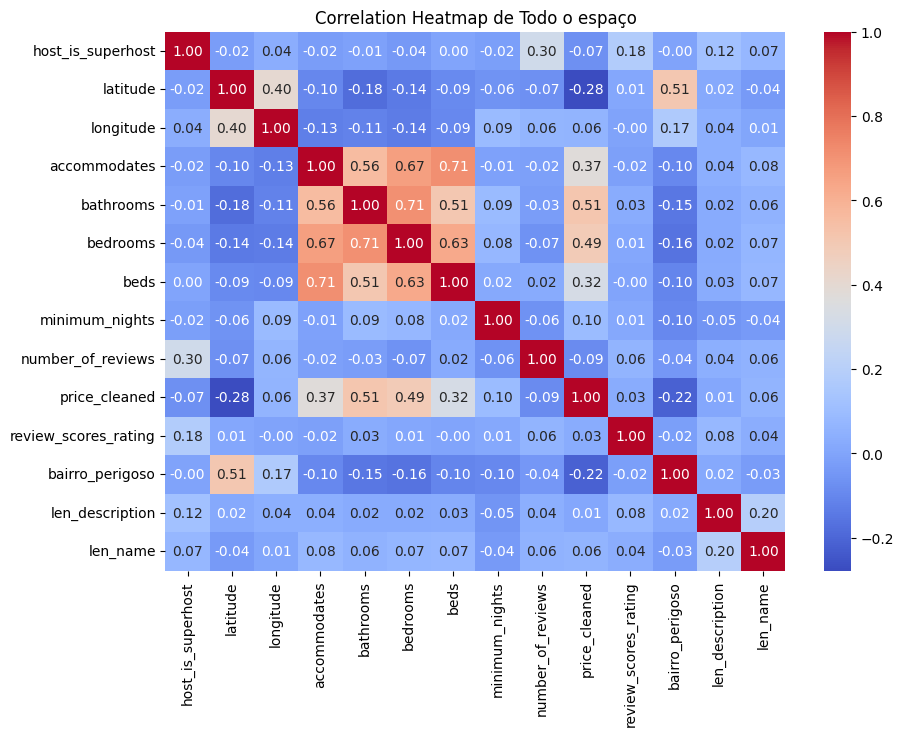

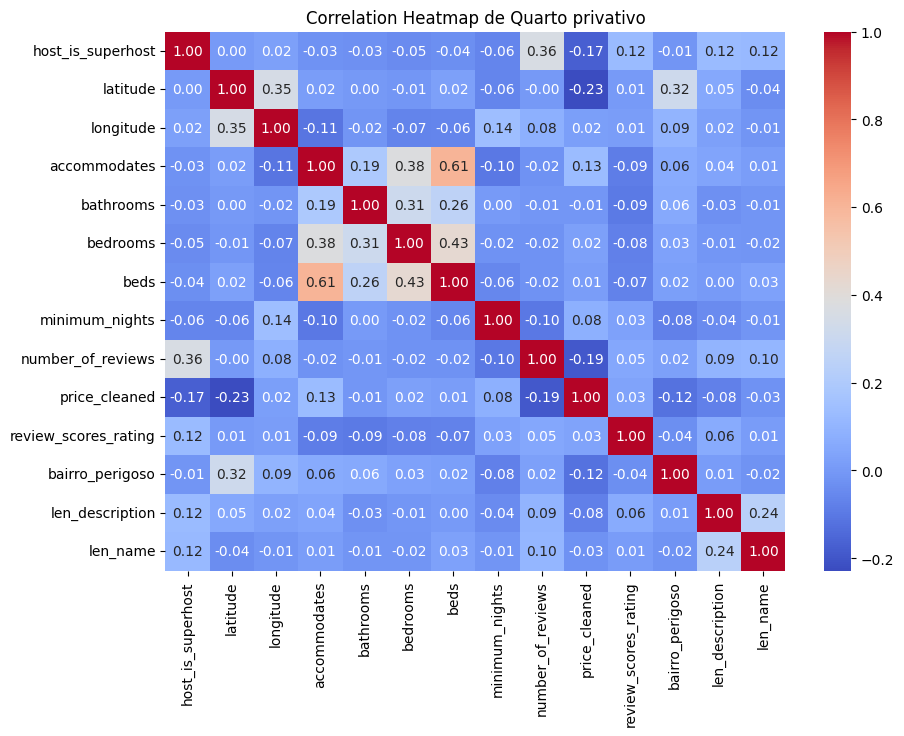

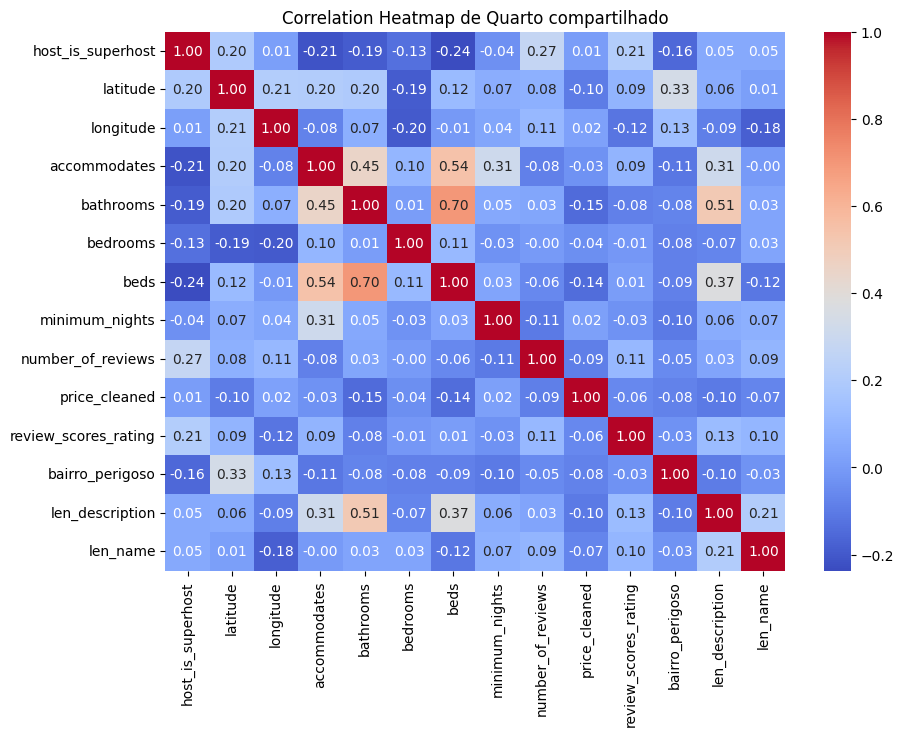

In [112]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'price_cleaned', 'review_scores_rating', 'bairro_perigoso', 'len_description', 'len_name'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

#### Arvore

In [154]:
cat_cols = ['host_is_superhost', 'bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']#, 'len_description', 'len_name']

In [155]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [156]:
modelos_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [157]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0621
Root mean squared error: 205.5638

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.1337
Root mean squared error: 172.5674

--- Treinando arvore_normal para o grupo: Todo o espaço ---
R² Score: 0.4395
Root mean squared error: 255.8577


Leve piora comparado ao modelo analisando tudo e comparando com "Todo o espaço"

In [158]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---


R² Score: -0.0173
Root mean squared error: 201.1884


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.1925
Root mean squared error: 166.6053


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.5083
Root mean squared error: 239.6373



Resultado muito bom com XGBoost, principalmente para os dados de todo o espaço

In [159]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro (%)'] = ((df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real'])*100

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto   erro (%)
0  1081832721595195443      285.00      449.317139  57.655136
1   710429014174296240      298.00      377.018372  26.516232
2   983276472737858458      351.50      406.178192  15.555673
3  1584401970901361277      374.21      705.480286  88.525236
4  1313673062703391395      662.00      976.885681  47.565813


#### Lasso

In [160]:
precomputador_lasso_quartos = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

In [161]:
from sklearn.base import clone

MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = clone(precomputador_lasso_quartos)
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    rmse = root_mean_squared_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: 0.0705
Root mean squared error: 192.3062


--- Treinando lasso para o grupo: Quarto privativo ---


/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.348e+02, tolerance: 5.622e+01
  model = cd_fast.enet_coordinate_descent(


R² Score: 0.2012
Root mean squared error: 165.7048


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: 0.4281
Root mean squared error: 258.4447



Modelos de lasso aqui se torna melhor que arvore regressora. $R^2_{Score}$ = 0.3342613615652218 em arvore sem separação de quartos.

Anuncios que se alugam todo o espaço esta prevendo melhor, provavelmente os outros ainda estão piorando a analise feita anteriormente, note ainda que quarto compartilhado é a pior predição de todas

In [162]:
for room in room_trad.values():
    df = dfs_por_quartos[room]
    print("O número de dados para o tipo de anúncio", room ,len(df))

O número de dados para o tipo de anúncio Todo o espaço 16245
O número de dados para o tipo de anúncio Quarto privativo 2193
O número de dados para o tipo de anúncio Quarto compartilhado 105


Talves o problema dos quartos compartilhados esteja na quantidade de dados, poucos para se tirar uma estatística concisa. O dataset tem apenas 333 dados no total. Ao dividir em treino e teste (80/20), o conjunto de treino tem 266, podendo pegar poucos outlier do teste que possui cerca de 66 imóveis.

In [163]:
dfs_por_quartos["Quarto compartilhado"].price_cleaned.describe()

count     105.000000
mean      149.647333
std       117.638941
min        49.150000
25%        92.000000
50%       120.000000
75%       168.000000
max      1022.000000
Name: price_cleaned, dtype: float64

Outlier grande de 1544 para o restante dos dados, como pode ser visto, e pode estar estragando a regressão ou o teste.

In [164]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['lasso'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['lasso'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro (%)'] = ((df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real'])*100

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto    erro (%)
0  1081832721595195443      285.00      404.077607   41.781617
1   710429014174296240      298.00      406.516647   36.414982
3  1584401970901361277      374.21      798.660204  113.425671
4  1313673062703391395      662.00      920.195114   39.002283
5             53191578     1122.33      739.536603   34.107027


In [165]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [166]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [167]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           30325
Quarto privativo         6236
Quarto compartilhado      565
Name: count, dtype: int64

# Previsão de Rating
Acredito que essa previsão seja extremamente difícil, devido a como cada tipo de pessoa da as notas, sem contar que acredito que é muito mais fácil alguém dar uma nota "ruim" do que "boa", afim de reclamar de algo.

Acredito ainda que clientes que pagam mais caro possuam uma exigência maior do que os que pagam mais caro, afinal, quanto mais se paga, mais cuidado, espaço, conforto, etc. se requer.

**Talvez fazer por multiclass**, em intervalos de 0-1, 1-2, 2-3, 3-4, 4-4,5 e 4,5-5. 

### Bairros Seguros e Perigosos

In [308]:
df_treatment.review_scores_rating.describe()

count    31360.000000
mean         4.808030
std          0.366833
min          0.000000
25%          4.770000
50%          4.910000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

In [309]:
colunas_desejadas = [
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 
    'review_scores_rating', 'price_cleaned', 'minimum_nights', 'room_type', 'len_description', 'len_name'
]

dfs_por_bairro = {
    nome_grupo: dados[colunas_desejadas].dropna().query("review_scores_rating >= 0 and number_of_reviews >=5")
    for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')
}

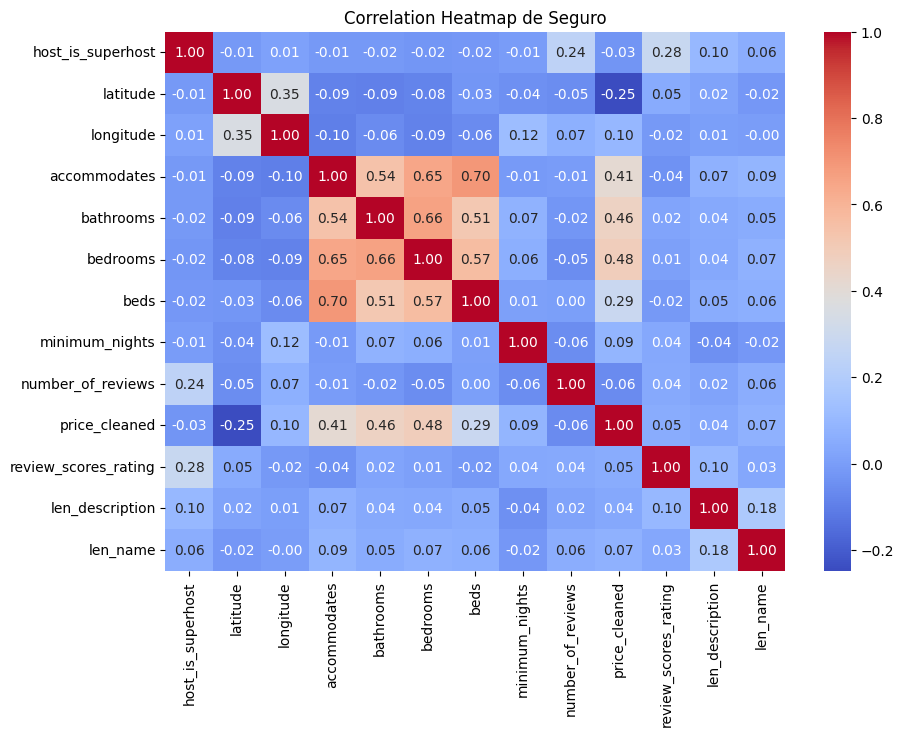

21358


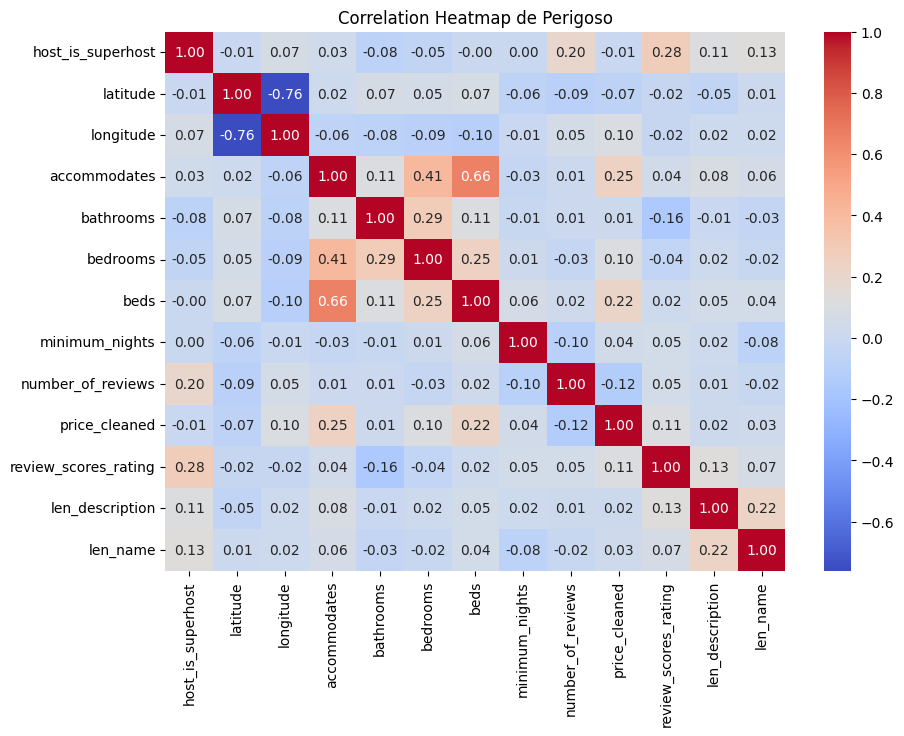

1811


In [310]:
for bairro, df_grupo in dfs_por_bairro.items():
    tipo_bairro = 'Seguro' if bairro == 0 else 'Perigoso'
    plt.figure(figsize=(10, 7))
    corr = df_grupo[[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {tipo_bairro}' )
    plt.show()
    print(len(df_grupo))

In [311]:
cat_cols = ['host_is_superhost', 'room_type']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']#, 'len_description', 'len_name']

In [312]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [313]:
modelos_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

#### Arvore Regressora

In [314]:
from sklearn.metrics import mean_absolute_error

MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = mean_absolute_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}")
    
    modelos_por_bairro[MODELO_ATUAL][status_bairro] = pipeline_atual
    
    predicoes_por_bairro[MODELO_ATUAL][status_bairro] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    
    metricas_por_bairro[MODELO_ATUAL][status_bairro] = {
        'R2': r2, 
        'MAE': mae
    }


--- Treinando arvore_normal para o grupo: Seguro ---
R² Score: 0.1089
Mean absolut error: 0.1258

--- Treinando arvore_normal para o grupo: Perigoso ---
R² Score: 0.0529
Mean absolut error: 0.1370


#### XGBoost

In [315]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.01,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_por_bairro[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_bairro[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_bairro[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_xgboost para o grupo: Seguro ---
R² Score: 0.1249
Mean absolut error: 0.1790


--- Treinando arvore_xgboost para o grupo: Perigoso ---
R² Score: 0.0959
Mean absolut error: 0.1849



In [316]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 0

y_real = predicoes_por_bairro['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_bairro['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_bairro[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['review_scores_rating'])
y_grupo = df_grupo_original['review_scores_rating'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'rating_real': y_real,            
    'rating_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro absoluto'] = (df_grupo['rating_previsto'] - df_grupo['rating_real'])
df_grupo['erro (%)'] = ((df_grupo['rating_real'] - df_grupo['rating_previsto']).abs() / df_grupo['rating_real'])*100

fig = px.line(df_grupo, y=['rating_real', 'rating_previsto'], 
              title=f"Nota Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para 0:
               id_imovel  rating_real  rating_previsto  erro absoluto  \
54   1542287955742361099         4.20         4.805736       0.605736   
79              38780989         4.05         4.758007       0.708007   
130  1206471313839278686         4.29         4.829100       0.539100   
139  1577864763853568826         3.86         4.802235       0.942235   
251  1366953040495416405         4.29         4.724083       0.434083   

      erro (%)  
54   14.422287  
79   17.481644  
130  12.566437  
139  24.410224  
251  10.118484  


#### Lasso

In [317]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.001, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Seguro ---
R² Score: 0.1183
Mean absolut error: 0.1251


--- Treinando lasso para o grupo: Perigoso ---
R² Score: 0.0886
Mean absolut error: 0.1345



In [318]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"MAE do Dummy (Média): {mean_absolute_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -0.0053604292000501985
MAE do Dummy (Média): 0.14


### Quartos

In [319]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna().query("review_scores_rating >= 4 and number_of_reviews >=10")
    for nome_grupo, dados in df_treatment.groupby('room_type')
}

In [320]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [321]:
cat_cols = ['host_is_superhost', 'bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned', 'len_description', 'len_name']

In [322]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [323]:
modelos_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [324]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = mean_absolute_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolute error: {mae:.4f}")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'mae': mae}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0188
Mean absolute error: 0.1527

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.0994
Mean absolute error: 0.1123

--- Treinando arvore_normal para o grupo: Todo o espaço ---
R² Score: 0.1704
Mean absolute error: 0.1040


In [325]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = mean_absolute_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': mae}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---


R² Score: 0.4180
Mean absolut error: 0.1131


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.1425
Mean absolut error: 0.1052


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.2044
Mean absolut error: 0.1018



In [326]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: -0.0188
Root mean squared error: 0.1405


--- Treinando lasso para o grupo: Quarto privativo ---
R² Score: -0.0004
Root mean squared error: 0.1405


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: -0.0009
Root mean squared error: 0.1405



### Preço

In [327]:
colunas_desejadas = [
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 
    'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name'
]
limites = [0, 200, 400, 600, 1000]
nomes_faixas = ['Barato', 'Médio', 'Caro', 'Muito caro']

df_treatment['faixa_preco'] = pd.cut(
    df_treatment['price_cleaned'], 
    bins=limites, 
    labels=nomes_faixas
)

colunas_finais = colunas_desejadas + ['faixa_preco']

dfs_por_precos = {
    nome_grupo: dados[colunas_finais].dropna().query("review_scores_rating >= 4 and number_of_reviews >= 10")
    for nome_grupo, dados in df_treatment.groupby('faixa_preco', observed=False)
}

In [329]:
cat_cols = ['bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_cleaned', 'len_description', 'len_name']

In [330]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [331]:
modelos_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [332]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolute error: {rmse:.4f}")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_normal para o grupo: Barato ---
R² Score: 0.1144
Mean absolute error: 0.1405

--- Treinando arvore_normal para o grupo: Médio ---
R² Score: 0.0156
Mean absolute error: 0.1405

--- Treinando arvore_normal para o grupo: Caro ---
R² Score: -0.0053
Mean absolute error: 0.1405

--- Treinando arvore_normal para o grupo: Muito caro ---
R² Score: 0.0014
Mean absolute error: 0.1405


In [333]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = mean_absolute_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {mae:.4f}\n")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_xgboost para o grupo: Barato ---
R² Score: 0.1301
Root mean squared error: 0.1201


--- Treinando arvore_xgboost para o grupo: Médio ---
R² Score: 0.0632
Root mean squared error: 0.1132


--- Treinando arvore_xgboost para o grupo: Caro ---
R² Score: -0.0192
Root mean squared error: 0.1170


--- Treinando arvore_xgboost para o grupo: Muito caro ---
R² Score: -0.0167
Root mean squared error: 0.1089



In [334]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {mae:.4f}\n")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Barato ---
R² Score: -0.0024
Root mean squared error: 0.1312


--- Treinando lasso para o grupo: Médio ---
R² Score: -0.0007
Root mean squared error: 0.1181


--- Treinando lasso para o grupo: Caro ---
R² Score: -0.0000
Root mean squared error: 0.1160


--- Treinando lasso para o grupo: Muito caro ---
R² Score: -0.0002
Root mean squared error: 0.1101



A faixa de preço não influencia tanto